In [1]:
from util import *

import matplotlib.pyplot as plt
from astropy.io import fits

SIMPLE  =                    T / Fits standard                                  BITPIX  =                  -32 / Bits per pixel                                 NAXIS   =                    1 / Number of axes                                 NAXIS1  =                  825 / Axis length                                    EXTEND  =                    T / File may contain extensions                    ORIGIN  = 'NOAO-IRAF FITS Image Kernel July 2003' / FITS file originator        DATE    = '2024-11-27T02:26:44' / Date FITS file was generated                  IRAF-TLM= '2024-11-27T02:26:44' / Time of last modification                     OBJECT  = '        '           / Name of the object observed                    NEXTEND =                    0 / Number of extensions                           CCDBIN1 =                    1 / Binning factor along axis 1                    CCDBIN2 =                    2 / Binning factor along axis 2                    FILENAME= 'TempImage2452.fits' / base fi

Text(0.02, 0.5, 'Normalized Flux')

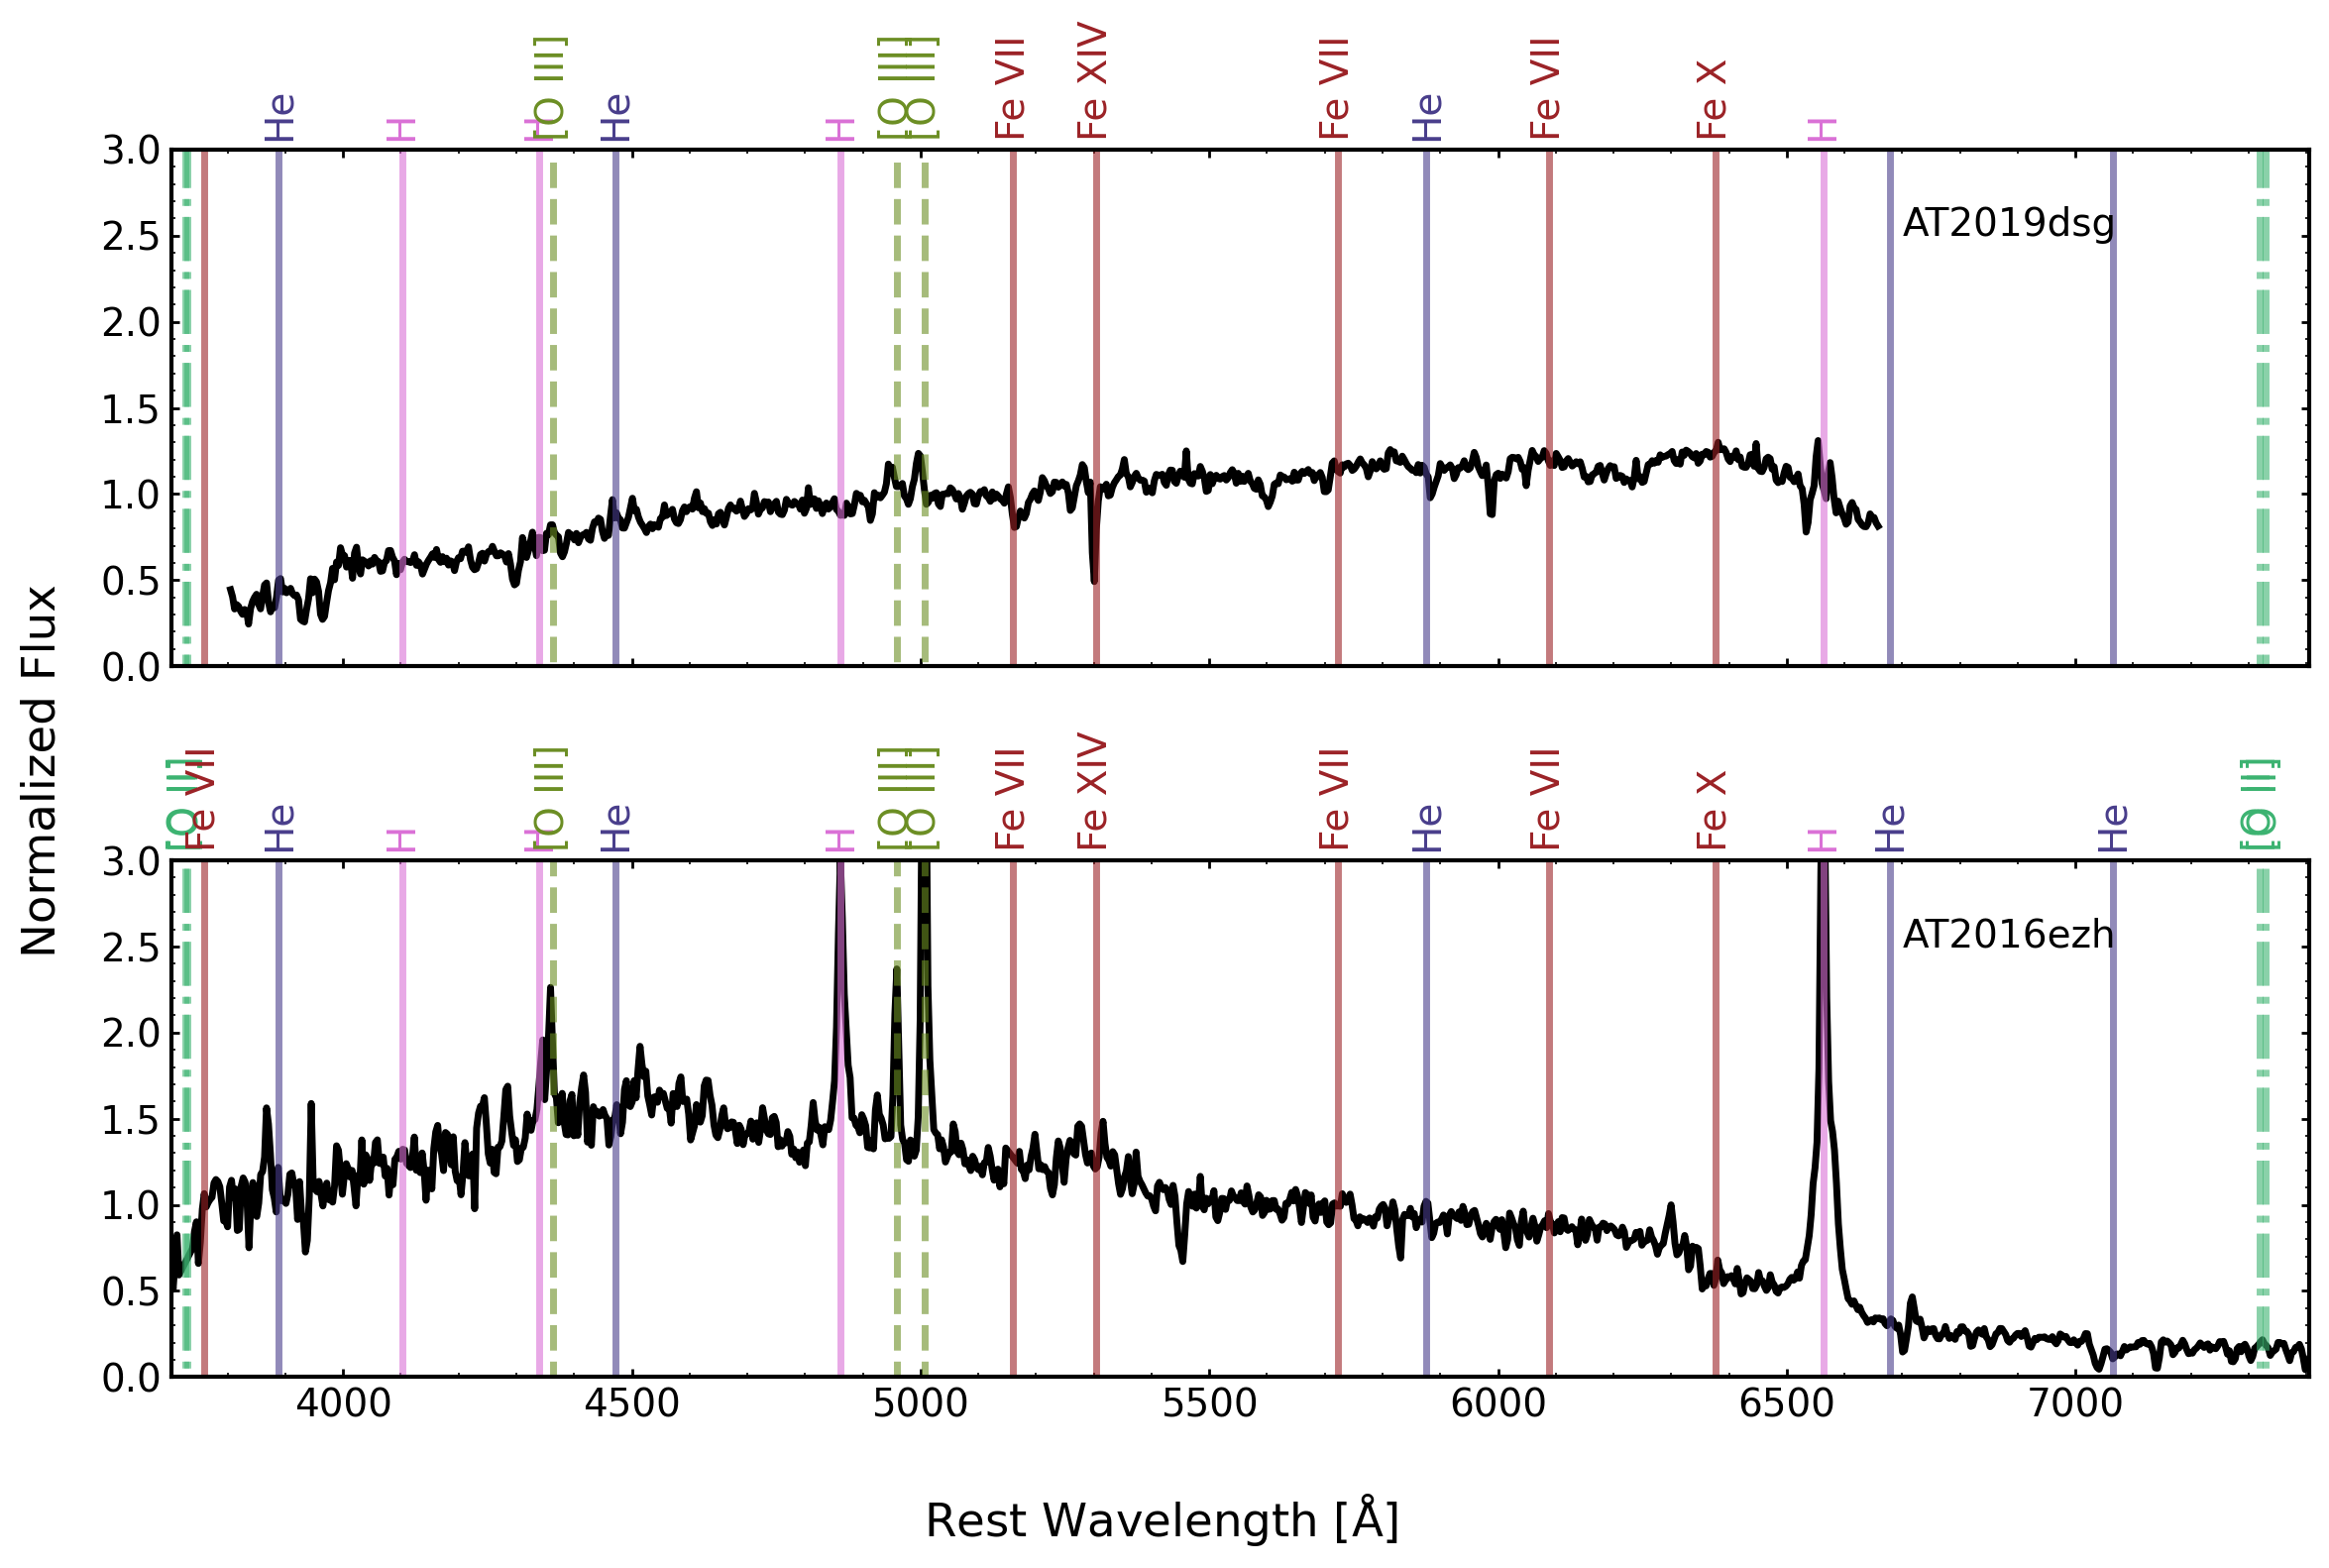

In [4]:
def read_and_plot(file, z, ax=None):
    spec = make_1d_spec(file)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(12,4))
    
    rest_wave = spec.wave/(1+z)

    ax.plot(rest_wave, spec.flux/np.nanmedian(spec.flux), color='k')

    linelist(
        ax=ax, 
        spacer=0, 
        start=3.1, 
        low=np.min(rest_wave), 
        high=np.max(rest_wave)
    )

    ax.set_xlim(np.min(rest_wave), np.max(rest_wave))
    ax.set_ylim(0,3)
    
    return ax

files = ["AT2019dsgHost_BokBC_20241106.fits", "AT2016ezh_BokBC_20241107.fits"]
zs = [0.0512, 0.0804]
labels = ["AT2019dsg", "AT2016ezh"]
fig, axs = plt.subplots(2,1,figsize=(12,8),sharex=True)

for file, z, label, ax in zip(files, zs, labels, axs):
    read_and_plot(file, z, ax=ax)
    ax.text(6700, 2.5, label)
    
fig.supxlabel(r"Rest Wavelength [$\AA$]")
fig.supylabel("Normalized Flux")